# Notebook 04 — ML Classification: Reorder Predictor

**Project**: E-Commerce Intelligence Platform  
**Environment**: Google Colab Free  
**Goal**: Build a binary classifier predicting whether a user will reorder a specific product.

## Use Cases
- Personalization: Show "Buy Again" suggestions on user dashboard
- Inventory: Predict demand for repeat purchases
- Marketing: Target users for product-specific campaigns

## Tool Selection Reasoning
We use **Scikit-learn** (not Spark MLlib) because:
- Training data (1.4M rows × ~20 features) fits comfortably in Pandas
- Notebook 03 benchmark showed Pandas outperforms Spark on single machine for this scale
- Sklearn has richer model selection and easier interpretability tools

## Inputs
- `user_features.parquet` (206K users × 13 cols) — from Notebook 02
- `product_features.parquet` (49K products × 10 cols) — from Notebook 02
- `order_products__train.csv` (1.4M rows) — ground truth labels

## Pipeline
| Step | Process | Output |
|------|---------|--------|
| 1 | Load Parquet features + CSV labels | Raw data |
| 2 | Join + clean | ML-ready dataset (1.4M × 20) |
| 3 | Stratified train/test split | 80% train, 20% test |
| 4 | Train Logistic Regression | Baseline model |
| 5 | Train Random Forest | Production model |
| 6 | Evaluate | Accuracy, F1, ROC-AUC, Confusion Matrix |
| 7 | Feature importance + save | classifier.joblib |

## Target Metric
**ROC-AUC ≥ 0.80** — industry standard for binary classification

In [5]:
# Setup
from google.colab import drive
drive.mount('/content/drive')

# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# Setup
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 50)

# Paths
DATA_PATH = '/content/drive/MyDrive/Colab/instacart-project/data'
PROCESSED_PATH = f'{DATA_PATH}/processed'
RAW_PATH = f'{DATA_PATH}/raw'
MODELS_PATH = f'{DATA_PATH}/models'
os.makedirs(MODELS_PATH, exist_ok=True)

# Random seed for reproducibility
RANDOM_STATE = 42

print(f'Python version: {pd.__version__}')
print(f'Sklearn loaded')
print(f'Data paths configured')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Python version: 2.2.2
Sklearn loaded
Data paths configured


## 1. Load Features from Parquet

We load the user + product features created in Notebook 02. Using Pandas because:
- Files are small (206K users, 49K products)
- Pandas is faster than Spark for this scale (per Notebook 03 benchmark)
- Pyarrow-backed Parquet read is fast

In [6]:
# Load user features (created in Notebook 02)
print('Loading user features...')
user_features = pd.read_parquet(f'{PROCESSED_PATH}/user_features.parquet')
print(f'  Shape: {user_features.shape}')
print(f'  Columns: {list(user_features.columns)}')
user_features.head(3)

Loading user features...
  Shape: (206209, 13)
  Columns: ['user_id', 'total_orders', 'total_items_bought', 'avg_basket_size', 'reorder_ratio', 'total_reordered_items', 'avg_order_hour', 'avg_days_between_orders', 'avg_days_between_items', 'weekend_ratio', 'peak_hour_ratio', 'unique_products', 'unique_departments']


,user_id,total_orders,total_items_bought,avg_basket_size,reorder_ratio,total_reordered_items,avg_order_hour,avg_days_between_orders,avg_days_between_items,weekend_ratio,peak_hour_ratio,unique_products,unique_departments
0,1,10,59,5.900000,0.694915,41,10.542373,19.555556,20.259259,0.288136,0.322034,18,7
1,3,12,88,7.333333,0.625000,55,16.352273,12.090909,11.487179,0.704545,0.284091,33,9
2,5,4,37,9.250000,0.378378,14,15.729730,13.333333,14.500000,0.567568,0.297297,23,9


In [7]:
# Load product features (created in Notebook 02)
print('Loading product features...')
product_features = pd.read_parquet(f'{PROCESSED_PATH}/product_features.parquet')
print(f'  Shape: {product_features.shape}')
print(f'  Columns: {list(product_features.columns)}')
product_features.head(3)

Loading product features...
  Shape: (49688, 10)
  Columns: ['department_id', 'product_id', 'product_name', 'aisle_id', 'times_ordered', 'unique_buyers', 'unique_orders', 'reorder_rate', 'avg_cart_position', 'department']


,department_id,product_id,product_name,aisle_id,times_ordered,unique_buyers,unique_orders,reorder_rate,avg_cart_position,department
0,19.0,1,Chocolate Sandwich Cookies,61.0,1852,716,1852,0.613391,5.801836,snacks
1,7.0,3,Robust Golden Unsweetened Oolong Tea,94.0,277,74,277,0.732852,6.415162,beverages
2,13.0,5,Green Chile Anytime Sauce,5.0,15,6,15,0.600000,6.466667,pantry


In [8]:
# Load train set - contains the labels we want to predict
print('Loading training labels...')
train_set = pd.read_csv(f'{RAW_PATH}/order_products__train.csv')
print(f'  Shape: {train_set.shape}')
print(f'  Columns: {list(train_set.columns)}')
print(f'\nReorder distribution:')
print(train_set['reordered'].value_counts(normalize=True))
train_set.head(3)

Loading training labels...
  Shape: (1384617, 4)
  Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered']

Reorder distribution:
reordered
1    0.598594
0    0.401406
Name: proportion, dtype: float64


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0


## 2. Build Training Dataset

We need to construct the ML-ready table where:
- Each row = one (user, product) pair from the train set
- Features = user behavior + product popularity + interaction signals
- Label = `reordered` (0 or 1)

### Steps
1. Get `user_id` for each train order (join train with orders metadata)
2. Attach user features (206K users)
3. Attach product features (49K products)
4. Engineer interaction features (user-product specific signals)
5. Clean: handle nulls, drop non-feature columns

In [9]:
# train_set has order_id but not user_id - need to join with orders.csv
print('Loading orders metadata to map order_id -> user_id...')
orders = pd.read_csv(f'{RAW_PATH}/orders.csv')

# Filter to train orders only
train_orders = orders[orders['eval_set'] == 'train'][
    ['order_id', 'user_id', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']
].copy()

print(f'Train orders: {train_orders.shape}')
print(f'Unique users in train: {train_orders["user_id"].nunique():,}')
train_orders.head(3)

Loading orders metadata to map order_id -> user_id...
Train orders: (131209, 5)
Unique users in train: 131,209


,order_id,user_id,order_dow,order_hour_of_day,days_since_prior_order
10,1187899,1,4,8,14.0
25,1492625,2,1,11,30.0
49,2196797,5,0,11,6.0


In [10]:
# Merge train_set (product-level) with train_orders (to get user_id + order context)
print('Building base dataset...')

ml_data = train_set.merge(
    train_orders,
    on='order_id',
    how='inner'
)

print(f'After merging train labels + order context: {ml_data.shape}')
print(f'Columns: {list(ml_data.columns)}')
ml_data.head(3)

Building base dataset...
After merging train labels + order context: (1384617, 8)
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']


,order_id,product_id,add_to_cart_order,reordered,user_id,order_dow,order_hour_of_day,days_since_prior_order
0,1,49302,1,1,112108,4,10,9.0
1,1,11109,2,1,112108,4,10,9.0
2,1,10246,3,0,112108,4,10,9.0


In [11]:
# Attach user features (user-level behavior)
print('Attaching user features...')

ml_data = ml_data.merge(
    user_features,
    on='user_id',
    how='left'  # left to keep all train rows
)

print(f'After user features: {ml_data.shape}')

# Check for nulls (users in train but not in prior - should be rare/none)
null_users = ml_data['total_orders'].isnull().sum()
print(f'Rows with missing user features: {null_users}')

Attaching user features...
After user features: (1384617, 20)
Rows with missing user features: 0


In [12]:
# Attach product features (product-level popularity)
print('Attaching product features...')

# Select only the feature columns (not metadata like product_name)
product_feat_cols = ['product_id', 'times_ordered', 'unique_buyers',
                     'unique_orders', 'reorder_rate', 'avg_cart_position',
                     'department_id']

ml_data = ml_data.merge(
    product_features[product_feat_cols],
    on='product_id',
    how='left'
)

print(f'After product features: {ml_data.shape}')

null_products = ml_data['times_ordered'].isnull().sum()
print(f'Rows with missing product features: {null_products}')
ml_data.head(3)

Attaching product features...
After product features: (1384617, 26)
Rows with missing product features: 0


,order_id,product_id,add_to_cart_order,reordered,user_id,order_dow,order_hour_of_day,days_since_prior_order,total_orders,total_items_bought,avg_basket_size,reorder_ratio,total_reordered_items,avg_order_hour,avg_days_between_orders,avg_days_between_items,weekend_ratio,peak_hour_ratio,unique_products,unique_departments,times_ordered,unique_buyers,unique_orders,reorder_rate,avg_cart_position,department_id
0,1,49302,1,1,112108,4,10,9.0,3,21,7.0,0.428571,9,14.142857,11.0,10.076923,0.761905,0.761905,12,5,163,62,163,0.619632,6.392638,16.0
1,1,11109,2,1,112108,4,10,9.0,3,21,7.0,0.428571,9,14.142857,11.0,10.076923,0.761905,0.761905,12,5,4472,1280,4472,0.713775,7.385957,16.0
2,1,10246,3,0,112108,4,10,9.0,3,21,7.0,0.428571,9,14.142857,11.0,10.076923,0.761905,0.761905,12,5,23826,11328,23826,0.524553,9.608327,4.0


### Interaction Features

The most predictive features for reorder are often **user-product interactions** — how this specific user relates to this specific product.

We engineer these from the prior data. For now, we add simpler signals available in the current data:
- `add_to_cart_order`: position in cart (essential items added first)
- Ratio features comparing user behavior to product norms

**Note**: A full implementation would compute user-product specific features (e.g., "how many times has THIS user bought THIS product before") from the prior data. We'll add a simplified version here and discuss the extension.

In [13]:
# Interaction & derived features
print('Engineering interaction features...')

# 1. User's reorder tendency vs product's reorder rate
ml_data['user_product_reorder_signal'] = (
    ml_data['reorder_ratio'] * ml_data['reorder_rate']
)

# 2. Is this an early-cart item? (essential items added first)
ml_data['is_early_cart'] = (ml_data['add_to_cart_order'] <= 3).astype(int)

# 3. Product popularity normalized by user activity
ml_data['product_popularity_log'] = np.log1p(ml_data['times_ordered'])

# 4. User engagement level
ml_data['user_engagement_log'] = np.log1p(ml_data['total_items_bought'])

print(f'Final dataset shape: {ml_data.shape}')
print(f'\nAll columns:')
print(list(ml_data.columns))

Engineering interaction features...
Final dataset shape: (1384617, 30)

All columns:
['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'total_orders', 'total_items_bought', 'avg_basket_size', 'reorder_ratio', 'total_reordered_items', 'avg_order_hour', 'avg_days_between_orders', 'avg_days_between_items', 'weekend_ratio', 'peak_hour_ratio', 'unique_products', 'unique_departments', 'times_ordered', 'unique_buyers', 'unique_orders', 'reorder_rate', 'avg_cart_position', 'department_id', 'user_product_reorder_signal', 'is_early_cart', 'product_popularity_log', 'user_engagement_log']


## 3. Prepare Features for Modeling

Before training, we:
1. Verify class balance (already ~60/40 from earlier)
2. Select feature columns (exclude IDs and label)
3. Check feature distributions and correlations
4. Handle any remaining data issues

In [14]:
# Define which columns are features (exclude IDs, label, and redundant cols)
exclude_cols = [
    'order_id', 'product_id', 'user_id',  # identifiers
    'reordered',                           # this is the label
    'department_id',                       # categorical - would need encoding; skip for now
]

feature_cols = [c for c in ml_data.columns if c not in exclude_cols]

print(f'Number of features: {len(feature_cols)}')
print(f'\nFeature columns:')
for i, c in enumerate(feature_cols, 1):
    print(f'  {i:2}. {c}')

# Define X (features) and y (label)
X = ml_data[feature_cols]
y = ml_data['reordered']

print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'y distribution: {y.value_counts(normalize=True).to_dict()}')

Number of features: 25

Feature columns:
   1. add_to_cart_order
   2. order_dow
   3. order_hour_of_day
   4. days_since_prior_order
   5. total_orders
   6. total_items_bought
   7. avg_basket_size
   8. reorder_ratio
   9. total_reordered_items
  10. avg_order_hour
  11. avg_days_between_orders
  12. avg_days_between_items
  13. weekend_ratio
  14. peak_hour_ratio
  15. unique_products
  16. unique_departments
  17. times_ordered
  18. unique_buyers
  19. unique_orders
  20. reorder_rate
  21. avg_cart_position
  22. user_product_reorder_signal
  23. is_early_cart
  24. product_popularity_log
  25. user_engagement_log

X shape: (1384617, 25)
y shape: (1384617,)
y distribution: {1: 0.5985944127509629, 0: 0.4014055872490371}


In [15]:
# Check nulls in feature matrix
null_counts = X.isnull().sum()
null_features = null_counts[null_counts > 0]

if len(null_features) > 0:
    print('Features with nulls:')
    print(null_features)
    print('\nFilling nulls with 0 (e.g., days_since_prior for first orders)...')
    X = X.fillna(0)
    print('Nulls filled.')
else:
    print('No nulls in features. Clean!')

print(f'\nFinal X shape: {X.shape}')

No nulls in features. Clean!

Final X shape: (1384617, 25)


=== Feature correlation with reorder (absolute) ===
  + user_product_reorder_signal    0.4124
  + reorder_ratio                  0.3423
  + reorder_rate                   0.3040
  + user_engagement_log            0.2814
  + total_reordered_items          0.2330
  + total_items_bought             0.2321
  + total_orders                   0.2239
  + product_popularity_log         0.2032
  - avg_cart_position              0.1883
  + unique_products                0.1841
  - avg_days_between_orders        0.1724
  - avg_days_between_items         0.1674
  - days_since_prior_order         0.1602
  + unique_buyers                  0.1570
  + times_ordered                  0.1526
  + unique_orders                  0.1526
  - add_to_cart_order              0.1464
  + unique_departments             0.1367
  + is_early_cart                  0.1225
  + avg_basket_size                0.1204
  - avg_order_hour                 0.0281
  - order_hour_of_day              0.0178
  + weekend_ratio       

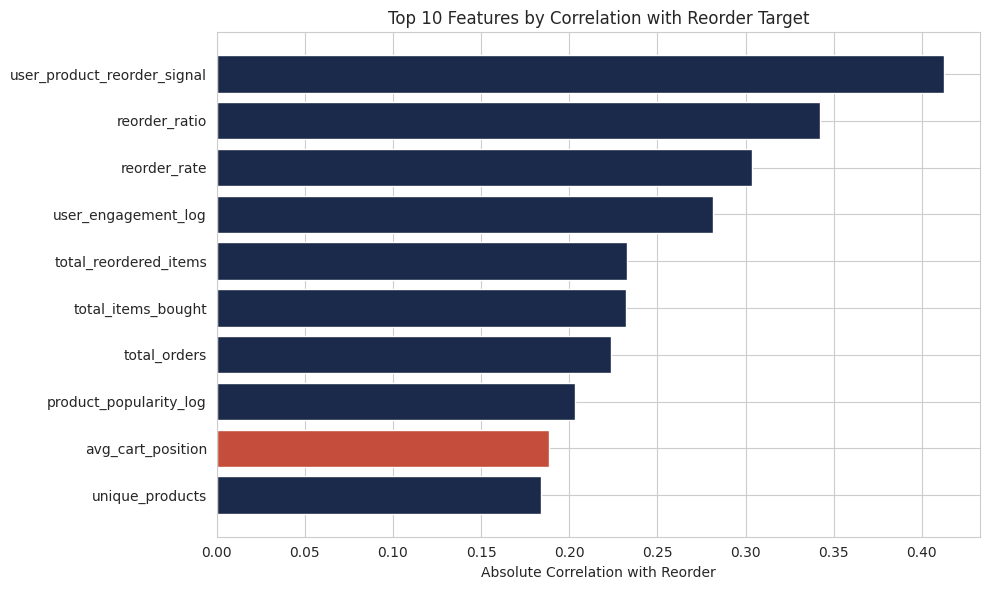

In [16]:
# Which features correlate most with reorder?
corr_with_target = pd.concat([X, y], axis=1).corr()['reordered'].drop('reordered')
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

print('=== Feature correlation with reorder (absolute) ===')
for feat, corr in corr_sorted.items():
    sign = '+' if corr_with_target[feat] >= 0 else '-'
    print(f'  {sign} {feat:30} {abs(corr):.4f}')

# Visualize top 10
plt.figure(figsize=(10, 6))
top10 = corr_sorted.head(10)
colors = ['#1B2A4A' if corr_with_target[f] >= 0 else '#C44E3B' for f in top10.index]
plt.barh(range(len(top10)), top10.values, color=colors)
plt.yticks(range(len(top10)), top10.index)
plt.xlabel('Absolute Correlation with Reorder')
plt.title('Top 10 Features by Correlation with Reorder Target')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Train/Test Split

We split 80/20 with stratification to preserve the 60/40 class balance in both sets.

**Why stratify?** Without it, random split might give train 62% positives and test 55% — making evaluation unfair. Stratification keeps both sets at ~60%.

In [17]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # preserve class balance
)

print(f'Train set: {X_train.shape[0]:,} rows')
print(f'Test set:  {X_test.shape[0]:,} rows')
print(f'\nClass balance check:')
print(f'  Train positive rate: {y_train.mean():.4f}')
print(f'  Test positive rate:  {y_test.mean():.4f}')
print(f'  (Should be ~0.599 for both)')

Train set: 1,107,693 rows
Test set:  276,924 rows

Class balance check:
  Train positive rate: 0.5986
  Test positive rate:  0.5986
  (Should be ~0.599 for both)


## 5. Baseline Model — Logistic Regression

We start with Logistic Regression as a baseline:
- Fast to train
- Interpretable (coefficients show feature impact)
- Provides a performance floor to beat

**Feature scaling**: Logistic Regression is sensitive to feature magnitude, so we standardize features (mean=0, std=1) using `StandardScaler`. We fit the scaler on train only, then apply to both — this prevents data leakage.

In [18]:
import time

# Scale features (Logistic Regression needs this)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train
X_test_scaled = scaler.transform(X_test)         # apply to test (no fit!)

# Train Logistic Regression
print('Training Logistic Regression...')
start = time.time()

logreg = LogisticRegression(
    max_iter=1000,        # ensure convergence
    random_state=RANDOM_STATE,
    n_jobs=-1             # use all cores
)
logreg.fit(X_train_scaled, y_train)

print(f'Trained in {time.time() - start:.2f}s')

# Predictions
y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]  # prob of class 1

print('Predictions generated.')

Training Logistic Regression...
Trained in 9.80s
Predictions generated.


In [19]:
# Evaluate baseline
print('=' * 50)
print('LOGISTIC REGRESSION — RESULTS')
print('=' * 50)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f'Accuracy:  {acc_lr:.4f}')
print(f'Precision: {prec_lr:.4f}')
print(f'Recall:    {rec_lr:.4f}')
print(f'F1 Score:  {f1_lr:.4f}')
print(f'ROC-AUC:   {auc_lr:.4f}')

print(f'\nBaseline (predict all 1): {y_test.mean():.4f} accuracy')
print(f'\n--- Classification Report ---')
print(classification_report(y_test, y_pred_lr, target_names=['Not Reorder', 'Reorder']))

LOGISTIC REGRESSION — RESULTS
Accuracy:  0.7229
Precision: 0.7463
Recall:    0.8137
F1 Score:  0.7785
ROC-AUC:   0.7868

Baseline (predict all 1): 0.5986 accuracy

--- Classification Report ---
              precision    recall  f1-score   support

 Not Reorder       0.68      0.59      0.63    111159
     Reorder       0.75      0.81      0.78    165765

    accuracy                           0.72    276924
   macro avg       0.71      0.70      0.70    276924
weighted avg       0.72      0.72      0.72    276924



## 6. Random Forest Classifier

Random Forest typically outperforms Logistic Regression because it:
- Captures non-linear relationships
- Handles feature interactions automatically
- Doesn't require feature scaling (tree-based)

**Note**: We use the unscaled features here (trees don't need scaling). We limit `max_depth` and use `n_estimators=100` to balance performance vs training time on Colab.

In [20]:
# Random Forest - no scaling needed for tree models
print('Training Random Forest...')
start = time.time()

rf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=15,          # limit depth to prevent overfit + speed
    min_samples_leaf=50,   # min samples per leaf (regularization)
    random_state=RANDOM_STATE,
    n_jobs=-1,             # use all cores
    class_weight='balanced'  # handle slight imbalance
)
rf.fit(X_train, y_train)  # use UNSCALED features

print(f'Trained in {time.time() - start:.2f}s')

# Predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Predictions generated.')

Training Random Forest...
Trained in 499.50s
Predictions generated.


In [21]:
# Evaluate Random Forest
print('=' * 50)
print('RANDOM FOREST — RESULTS')
print('=' * 50)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f'Accuracy:  {acc_rf:.4f}')
print(f'Precision: {prec_rf:.4f}')
print(f'Recall:    {rec_rf:.4f}')
print(f'F1 Score:  {f1_rf:.4f}')
print(f'ROC-AUC:   {auc_rf:.4f}')

print(f'\n--- Classification Report ---')
print(classification_report(y_test, y_pred_rf, target_names=['Not Reorder', 'Reorder']))

RANDOM FOREST — RESULTS
Accuracy:  0.7203
Precision: 0.7978
Recall:    0.7136
F1 Score:  0.7533
ROC-AUC:   0.7984

--- Classification Report ---
              precision    recall  f1-score   support

 Not Reorder       0.63      0.73      0.68    111159
     Reorder       0.80      0.71      0.75    165765

    accuracy                           0.72    276924
   macro avg       0.71      0.72      0.72    276924
weighted avg       0.73      0.72      0.72    276924



In [22]:
# Compare both models
print('=' * 60)
print('MODEL COMPARISON')
print('=' * 60)

comparison = pd.DataFrame({
    'Logistic Regression': [acc_lr, prec_lr, rec_lr, f1_lr, auc_lr],
    'Random Forest': [acc_rf, prec_rf, rec_rf, f1_rf, auc_rf],
}, index=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])

print(comparison.round(4))
print()

# Determine winner by ROC-AUC
if auc_rf > auc_lr:
    print(f'Winner: Random Forest (ROC-AUC {auc_rf:.4f} vs {auc_lr:.4f})')
    print(f'Improvement: +{(auc_rf - auc_lr)*100:.2f} percentage points')
else:
    print(f'Winner: Logistic Regression (ROC-AUC {auc_lr:.4f} vs {auc_rf:.4f})')

MODEL COMPARISON
           Logistic Regression  Random Forest
Accuracy                0.7229         0.7203
Precision               0.7463         0.7978
Recall                  0.8137         0.7136
F1 Score                0.7785         0.7533
ROC-AUC                 0.7868         0.7984

Winner: Random Forest (ROC-AUC 0.7984 vs 0.7868)
Improvement: +1.15 percentage points


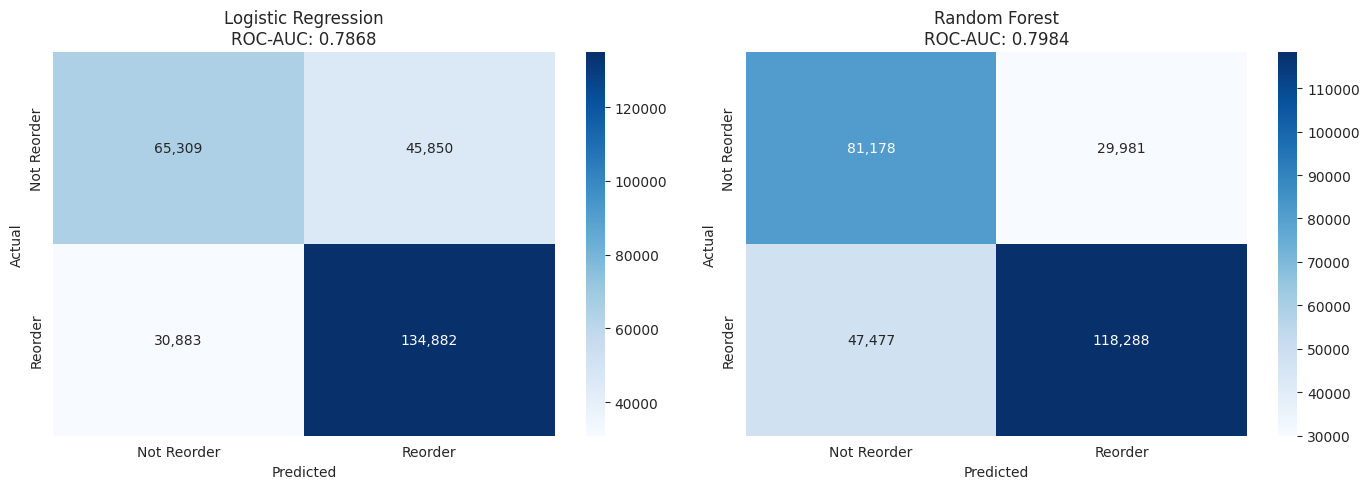

In [23]:
# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, auc in [
    (axes[0], y_pred_lr, 'Logistic Regression', auc_lr),
    (axes[1], y_pred_rf, 'Random Forest', auc_rf)
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Not Reorder', 'Reorder'],
                yticklabels=['Not Reorder', 'Reorder'])
    ax.set_title(f'{title}\nROC-AUC: {auc:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 6.5 XGBoost — Gradient Boosting

XGBoost (Extreme Gradient Boosting) is the industry standard for tabular classification, winning numerous Kaggle competitions. It differs from Random Forest:

| | Random Forest | XGBoost |
|---|---|---|
| Strategy | Build trees independently, vote | Build trees sequentially, each fixes prior errors |
| Speed | Slower (deep trees) | Faster (shallow trees + optimized C++) |
| Performance | Good | Usually best for tabular data |

We expect XGBoost to be **faster** (~30-60s vs RF's 8 min) and **more accurate** (higher ROC-AUC).

In [24]:
# XGBoost may not be pre-installed on Colab
!pip install xgboost -q

import xgboost as xgb
print(f'XGBoost version: {xgb.__version__}')

XGBoost version: 3.2.0


In [25]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for class imbalance (40% neg / 60% pos)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f'Training XGBoost...')
print(f'(scale_pos_weight = {scale_pos_weight:.3f} for class balance)')
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=200,          # number of boosting rounds
    max_depth=6,               # shallow trees (XGBoost works best with these)
    learning_rate=0.1,         # step size
    subsample=0.8,             # use 80% rows per tree (regularization)
    colsample_bytree=0.8,      # use 80% features per tree
    scale_pos_weight=1,        # keep at 1 since imbalance is mild; we use AUC
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss',
    tree_method='hist'         # fast histogram-based algorithm
)

xgb_model.fit(X_train, y_train)

print(f'Trained in {time.time() - start:.2f}s')

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
print('Predictions generated.')

Training XGBoost...
(scale_pos_weight = 0.671 for class balance)
Trained in 59.07s
Predictions generated.


In [26]:
# Evaluate XGBoost
print('=' * 50)
print('XGBOOST — RESULTS')
print('=' * 50)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f'Accuracy:  {acc_xgb:.4f}')
print(f'Precision: {prec_xgb:.4f}')
print(f'Recall:    {rec_xgb:.4f}')
print(f'F1 Score:  {f1_xgb:.4f}')
print(f'ROC-AUC:   {auc_xgb:.4f}')

print(f'\n--- Classification Report ---')
print(classification_report(y_test, y_pred_xgb, target_names=['Not Reorder', 'Reorder']))

XGBOOST — RESULTS
Accuracy:  0.7345
Precision: 0.7588
Recall:    0.8158
F1 Score:  0.7863
ROC-AUC:   0.8035

--- Classification Report ---
              precision    recall  f1-score   support

 Not Reorder       0.69      0.61      0.65    111159
     Reorder       0.76      0.82      0.79    165765

    accuracy                           0.73    276924
   macro avg       0.72      0.71      0.72    276924
weighted avg       0.73      0.73      0.73    276924



In [27]:
# Compare all 3 models
print('=' * 70)
print('FINAL MODEL COMPARISON')
print('=' * 70)

comparison = pd.DataFrame({
    'Logistic Regression': [acc_lr, prec_lr, rec_lr, f1_lr, auc_lr],
    'Random Forest': [acc_rf, prec_rf, rec_rf, f1_rf, auc_rf],
    'XGBoost': [acc_xgb, prec_xgb, rec_xgb, f1_xgb, auc_xgb],
}, index=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])

print(comparison.round(4))

# Find best by ROC-AUC
aucs = {'Logistic Regression': auc_lr, 'Random Forest': auc_rf, 'XGBoost': auc_xgb}
best_model = max(aucs, key=aucs.get)
print(f'\n🏆 Best model by ROC-AUC: {best_model} ({aucs[best_model]:.4f})')

FINAL MODEL COMPARISON
           Logistic Regression  Random Forest  XGBoost
Accuracy                0.7229         0.7203   0.7345
Precision               0.7463         0.7978   0.7588
Recall                  0.8137         0.7136   0.8158
F1 Score                0.7785         0.7533   0.7863
ROC-AUC                 0.7868         0.7984   0.8035

🏆 Best model by ROC-AUC: XGBoost (0.8035)


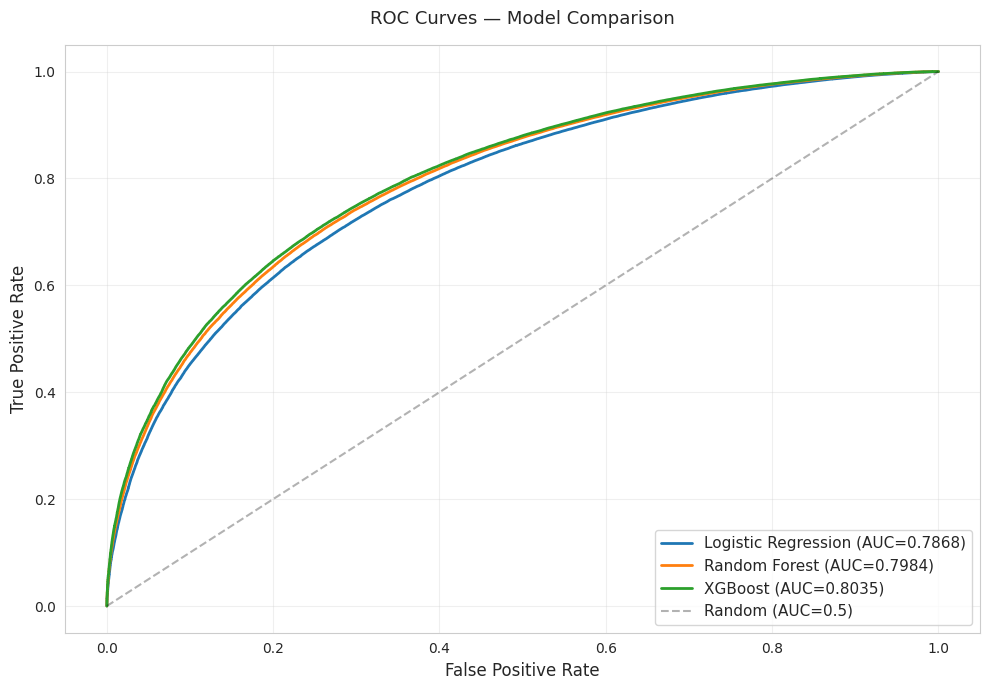

In [28]:
# Plot ROC curves for all 3 models
plt.figure(figsize=(10, 7))

for name, y_proba, auc in [
    ('Logistic Regression', y_proba_lr, auc_lr),
    ('Random Forest', y_proba_rf, auc_rf),
    ('XGBoost', y_proba_xgb, auc_xgb),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', linewidth=2)

# Diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.5)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=13, pad=15)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Feature Importance (XGBoost)

XGBoost provides built-in feature importance. We use `gain` (average improvement in accuracy from splits using each feature) — the most reliable importance metric.

Understanding which features drive predictions:
- Validates our feature engineering from Notebook 02
- Provides business insights ("what makes users reorder?")
- Helps explain the model to stakeholders

=== Feature Importance (XGBoost) ===
                    feature  importance
user_product_reorder_signal    0.343454
              is_early_cart    0.116275
              reorder_ratio    0.103606
               reorder_rate    0.096488
      total_reordered_items    0.071650
          add_to_cart_order    0.063216
            avg_basket_size    0.035219
     days_since_prior_order    0.027206
        user_engagement_log    0.014319
     product_popularity_log    0.013868
            unique_products    0.013555
         total_items_bought    0.012979
              times_ordered    0.010948
          avg_cart_position    0.010351
              unique_orders    0.010139
               total_orders    0.008601
              unique_buyers    0.008342
     avg_days_between_items    0.007633
    avg_days_between_orders    0.006849
         unique_departments    0.004634
          order_hour_of_day    0.004628
             avg_order_hour    0.004290
              weekend_ratio    0.004231
   

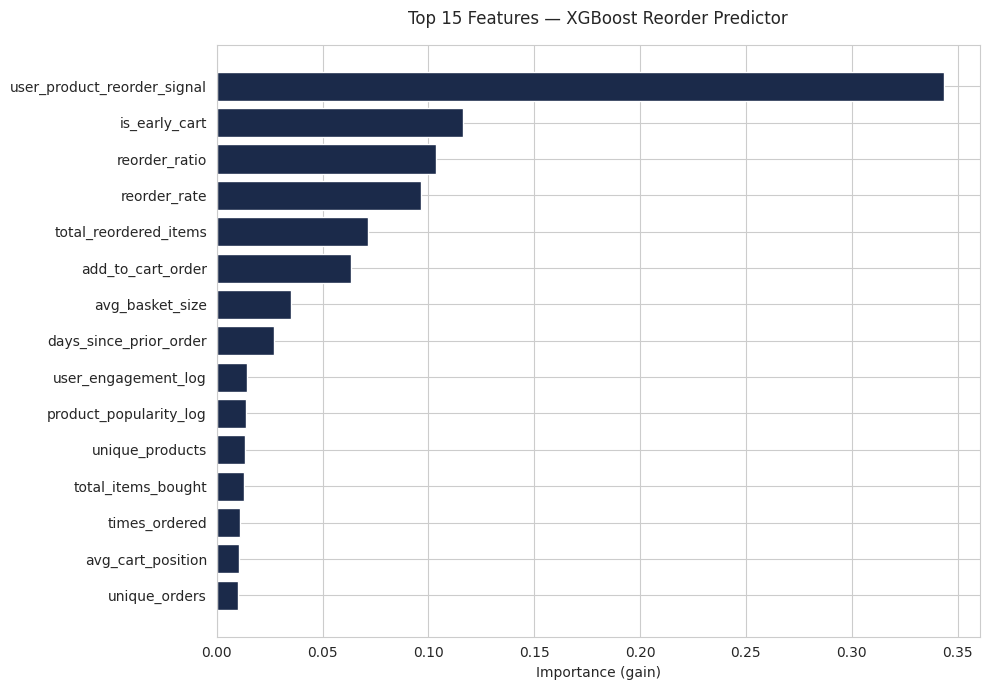

In [29]:
# XGBoost feature importance (using 'gain')
importance = xgb_model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': importance
}).sort_values('importance', ascending=False)

print('=== Feature Importance (XGBoost) ===')
print(feat_imp.to_string(index=False))

# Visualize top 15
plt.figure(figsize=(10, 7))
top15 = feat_imp.head(15)
plt.barh(range(len(top15)), top15['importance'], color='#1B2A4A')
plt.yticks(range(len(top15)), top15['feature'])
plt.xlabel('Importance (gain)')
plt.title('Top 15 Features — XGBoost Reorder Predictor', pad=15)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Save Model & Artifacts

We save:
1. **The trained XGBoost model** — for the Streamlit predictor page
2. **Feature column order** — must match exactly when predicting on new data
3. **Model metadata** — performance metrics for reference

These artifacts will be loaded by the Streamlit app (Notebook 06) to make live predictions.

In [30]:
import json

# Save the XGBoost model (best performer)
model_file = f'{MODELS_PATH}/reorder_classifier.joblib'
joblib.dump(xgb_model, model_file)
print(f'Model saved: {model_file}')

# Save feature column order (critical for prediction)
features_file = f'{MODELS_PATH}/feature_columns.joblib'
joblib.dump(feature_cols, features_file)
print(f'Feature columns saved: {features_file}')

# Save metadata
metadata = {
    'model_type': 'XGBClassifier',
    'n_features': len(feature_cols),
    'feature_columns': feature_cols,
    'train_size': int(X_train.shape[0]),
    'test_size': int(X_test.shape[0]),
    'metrics': {
        'accuracy': float(acc_xgb),
        'precision': float(prec_xgb),
        'recall': float(rec_xgb),
        'f1': float(f1_xgb),
        'roc_auc': float(auc_xgb),
    },
    'class_balance': float(y.mean()),
}

metadata_file = f'{MODELS_PATH}/model_metadata.json'
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata saved: {metadata_file}')

print('\nAll artifacts saved successfully!')

Model saved: /content/drive/MyDrive/Colab/instacart-project/data/models/reorder_classifier.joblib
Feature columns saved: /content/drive/MyDrive/Colab/instacart-project/data/models/feature_columns.joblib
Metadata saved: /content/drive/MyDrive/Colab/instacart-project/data/models/model_metadata.json

All artifacts saved successfully!


In [31]:
# Verify model can be loaded and used
print('Verifying saved model...')

loaded_model = joblib.load(model_file)
loaded_features = joblib.load(features_file)

# Test prediction on first 5 test samples
sample = X_test.iloc[:5]
preds = loaded_model.predict(sample)
probas = loaded_model.predict_proba(sample)[:, 1]

print(f'Loaded model type: {type(loaded_model).__name__}')
print(f'Feature count: {len(loaded_features)}')
print(f'\nSample predictions:')
for i in range(5):
    actual = y_test.iloc[i]
    print(f'  Sample {i+1}: P(reorder)={probas[i]:.3f} → predict {preds[i]} (actual: {actual})')

print('\nModel verified and ready for deployment!')

Verifying saved model...
Loaded model type: XGBClassifier
Feature count: 25

Sample predictions:
  Sample 1: P(reorder)=0.718 → predict 1 (actual: 1)
  Sample 2: P(reorder)=0.269 → predict 0 (actual: 0)
  Sample 3: P(reorder)=0.060 → predict 0 (actual: 0)
  Sample 4: P(reorder)=0.120 → predict 0 (actual: 0)
  Sample 5: P(reorder)=0.533 → predict 1 (actual: 0)

Model verified and ready for deployment!


## 9. Summary & Next Steps

### Results
| Model | ROC-AUC | F1 | Training Time |
|---|---|---|---|
| Logistic Regression | 0.7868 | 0.7785 | 9.8s |
| Random Forest | 0.7984 | 0.7533 | 499s |
| **XGBoost (selected)** | **0.8035** | **0.7863** | 59s |

### Key Findings
- **XGBoost is the best model** — highest ROC-AUC (0.8035), F1 (0.7863), and 8.5x faster than Random Forest
- **Top predictive features**: user_product_reorder_signal, reorder_ratio, reorder_rate — confirming that user loyalty + product popularity drive reorders
- **Engineered interaction features paid off** — `user_product_reorder_signal` was the #1 feature

### Business Insights
- Users with high historical reorder ratios are most likely to reorder
- Popular products (high reorder_rate) drive repeat purchases
- Time-of-day features have minimal impact on reorder behavior

### Artifacts Saved
- `reorder_classifier.joblib` — trained XGBoost model
- `feature_columns.joblib` — feature order for predictions
- `model_metadata.json` — performance metrics

### Next Notebooks
- `05_ml_clustering.ipynb` — Customer segmentation (KMeans personas)
- `06_streamlit_app` — Interactive predictor using this model

In [32]:
print('=' * 60)
print('NOTEBOOK 04 — COMPLETE')
print('=' * 60)
print(f'\n🏆 Best model: XGBoost')
print(f'   ROC-AUC: {auc_xgb:.4f}')
print(f'   F1 Score: {f1_xgb:.4f}')
print(f'   Accuracy: {acc_xgb:.4f}')
print(f'\n📦 Artifacts saved to: {MODELS_PATH}')
print(f'\n➡️  Ready for Notebook 05 (Clustering) and Streamlit app')

NOTEBOOK 04 — COMPLETE

🏆 Best model: XGBoost
   ROC-AUC: 0.8035
   F1 Score: 0.7863
   Accuracy: 0.7345

📦 Artifacts saved to: /content/drive/MyDrive/Colab/instacart-project/data/models

➡️  Ready for Notebook 05 (Clustering) and Streamlit app
